- Nama  : Muhammad Zaidaan Ardiyansyah
- NIM   : 24060124140200
- Tugas : Operator Robert 2x2 

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["image.cmap"] = "gray"

THRESHOLD = 50

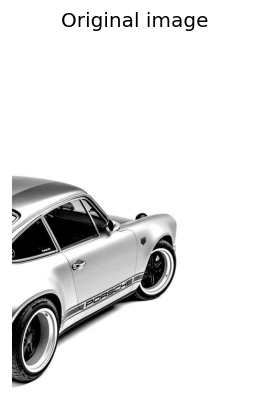

In [4]:
# Load image
img = cv2.imread("porsche.jpg", 0)

plt.figure(figsize=(6, 4))
plt.imshow(img, cmap="gray")
plt.title("Original image")
plt.axis("off")
plt.show()

In [5]:
def convolve2d(image, kernel):
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    h, w = image.shape
    padded = np.pad(image, ((ph, ph), (pw, pw)), mode="edge")
    result = np.zeros_like(image, dtype=np.float64)
    for y in range(h):
        for x in range(w):
            result[y, x] = np.sum(padded[y : y + kh, x : x + kw] * kernel)
    return result


def detect_edges(image, kernel_x, kernel_y, threshold=30):
    dx = convolve2d(image, kernel_x)
    dy = convolve2d(image, kernel_y)
    magnitude = np.abs(dx) + np.abs(dy)
    magnitude = np.clip(magnitude, 0, 255).astype(np.uint8)
    binary = (magnitude > threshold).astype(np.uint8) * 255
    return binary


def show_result(name, original, kernel_x, kernel_y, threshold=30):
    binary = detect_edges(original, kernel_x, kernel_y, threshold)
    plt.figure(figsize=(5, 4))
    plt.imshow(binary)
    plt.title(f"Operator {name}")
    plt.axis("off")
    plt.show()

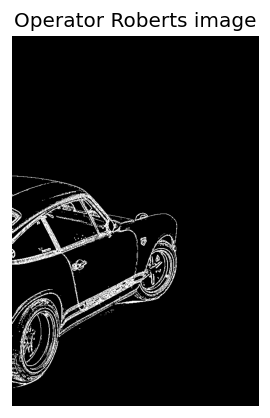

In [6]:
kernel_roberts_x = np.array([[1, 0],
                            [0, -1]], dtype=np.float64)
kernel_roberts_y = np.array([[0, 1], 
                            [-1, 0]], dtype=np.float64)

show_result(
    "Roberts image", img, kernel_roberts_x, kernel_roberts_y, threshold=THRESHOLD
)